In [2]:
import yfinance as yf
from backend.data_loader import load_data

In [4]:
Pinterest = load_data(ticker = 'PINS', period = '5Y')
Reddit = yf.download(tickers = 'RDDT', period = '5Y')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
print(Pinterest.head())
print(Reddit.head())

Price           Close       High        Low       Open    Volume
Ticker           PINS       PINS       PINS       PINS      PINS
Date                                                            
2021-05-05  61.830002  63.119999  61.250000  62.900002  13432300
2021-05-06  59.220001  61.075001  57.049999  61.040001  25708600
2021-05-07  59.860001  61.330002  58.910000  60.099998  15522400
2021-05-10  58.360001  60.139999  57.195000  58.509998  17872200
2021-05-11  59.709999  60.340000  55.603001  55.860001  16676700
Price           Close       High        Low       Open    Volume
Ticker           RDDT       RDDT       RDDT       RDDT      RDDT
Date                                                            
2024-03-21  50.439999  57.799999  45.049999  47.000000  48705500
2024-03-22  46.000000  51.000000  45.340000  48.880001  15983100
2024-03-25  59.799999  61.939999  46.080002  47.090000  24398800
2024-03-26  65.110001  74.900002  63.209999  67.709999  35331000
2024-03-27  57.750000  63

In [17]:
print(Pinterest.describe())
print(Reddit.describe())

Price         Close         High          Low         Open        Volume
Ticker         PINS         PINS         PINS         PINS          PINS
count   1256.000000  1256.000000  1256.000000  1256.000000  1.256000e+03
mean      32.605191    33.214970    31.998949    32.608113  1.218225e+07
std       11.876386    12.035425    11.674448    11.877455  8.386271e+06
min       15.420000    15.485000    13.840000    14.330000  1.956300e+06
25%       24.985000    25.454999    24.507500    24.992500  7.728450e+06
50%       29.950000    30.575001    29.477500    30.060000  1.016960e+07
75%       36.122499    36.577499    35.456250    36.112500  1.384640e+07
max       80.290001    81.769997    79.389999    81.190002  1.133763e+08
Price        Close        High         Low        Open        Volume
Ticker        RDDT        RDDT        RDDT        RDDT          RDDT
count   530.000000  530.000000  530.000000  530.000000  5.300000e+02
mean    137.138358  141.382957  133.031827  137.206372  6.09024

In [18]:
Pinterest.isnull().sum()

Price   Ticker
Close   PINS      0
High    PINS      0
Low     PINS      0
Open    PINS      0
Volume  PINS      0
dtype: int64

In [19]:
Reddit.isnull().sum()

Price   Ticker
Close   RDDT      0
High    RDDT      0
Low     RDDT      0
Open    RDDT      0
Volume  RDDT      0
dtype: int64

In [20]:
Pinterest.info()
Reddit.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1256 entries, 2021-05-03 to 2026-05-01
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, PINS)   1256 non-null   float64
 1   (High, PINS)    1256 non-null   float64
 2   (Low, PINS)     1256 non-null   float64
 3   (Open, PINS)    1256 non-null   float64
 4   (Volume, PINS)  1256 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB
<class 'pandas.DataFrame'>
DatetimeIndex: 530 entries, 2024-03-21 to 2026-05-01
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, RDDT)   530 non-null    float64
 1   (High, RDDT)    530 non-null    float64
 2   (Low, RDDT)     530 non-null    float64
 3   (Open, RDDT)    530 non-null    float64
 4   (Volume, RDDT)  530 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 24.8 KB


In [21]:
Pinterest['Close']

Ticker,PINS
Date,
2021-05-03,63.709999
2021-05-04,62.299999
2021-05-05,61.830002
2021-05-06,59.220001
2021-05-07,59.860001
...,...
2026-04-27,20.330000
2026-04-28,19.879999
2026-04-29,19.730000


In [22]:
Reddit['Close']

Ticker,RDDT
Date,
2024-03-21,50.439999
2024-03-22,46.000000
2024-03-25,59.799999
2024-03-26,65.110001
2024-03-27,57.750000
...,...
2026-04-27,160.210007
2026-04-28,147.929993
2026-04-29,147.750000


In [23]:
from scipy.stats import pearsonr

In [24]:
pc, pp = pearsonr(Pinterest['Close'], Pinterest['Volume'])
rc, rp = pearsonr(Reddit['Close'], Reddit['Volume'])
print("Pinterest Correlation and P-Value:", pc, pp)
print("Reddit Correlation and P-Value:", rc, rp)

Pinterest Correlation and P-Value: [-0.15803886] [1.7942174e-08]
Reddit Correlation and P-Value: [0.02698007] [0.53540644]


<Axes: title={'center': 'Closing Price'}, xlabel='Date'>

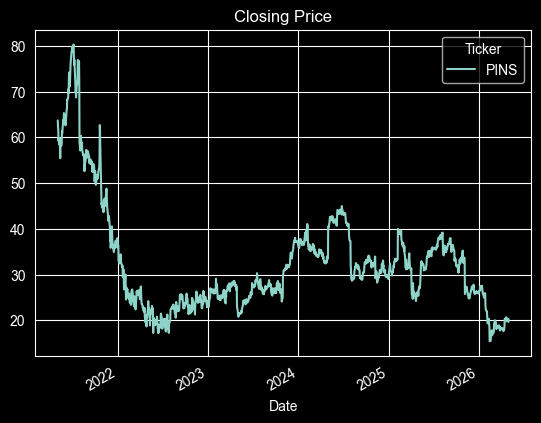

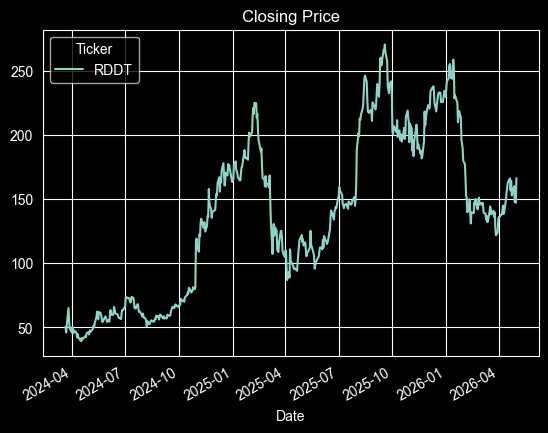

In [25]:
Pinterest['Close'].plot(title = "Closing Price")
Reddit['Close'].plot(title = "Closing Price")

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

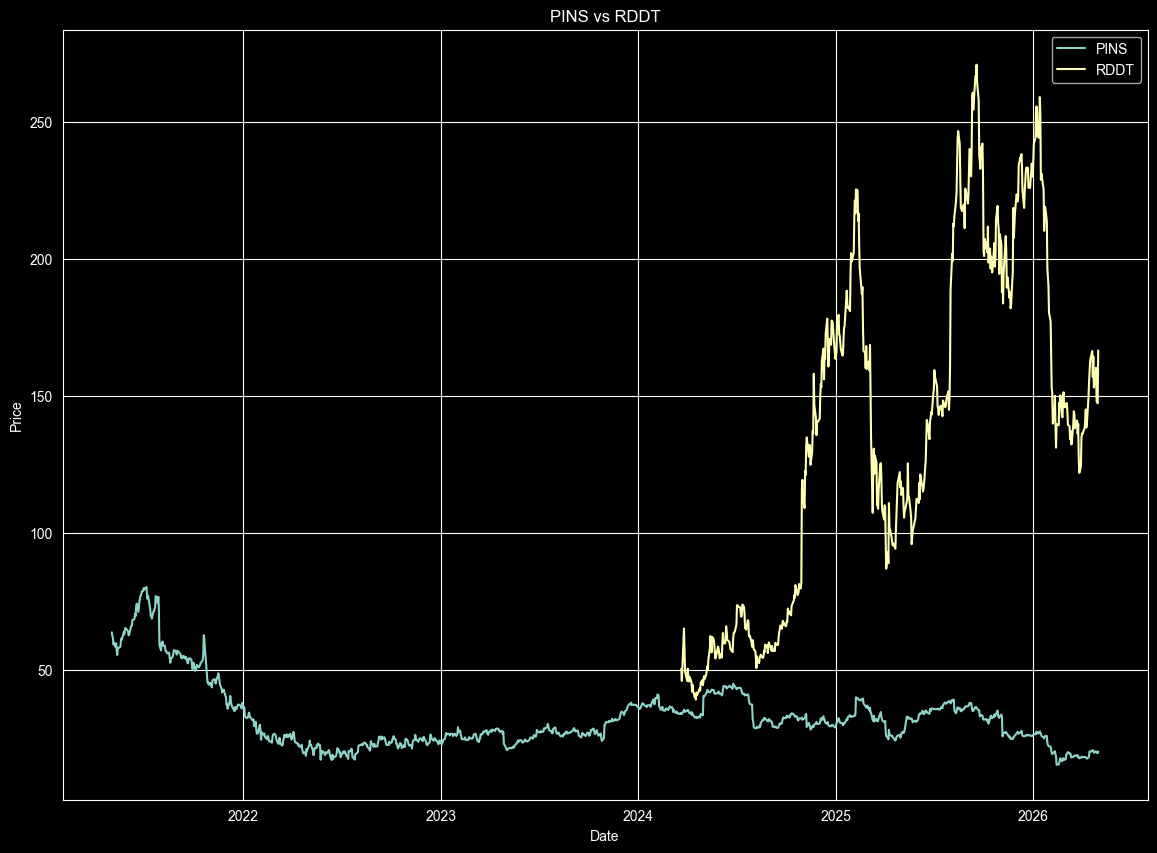

In [27]:
plt.figure(figsize=(14,10))
plt.plot(Pinterest['Close']["PINS"],label = "PINS")
plt.plot(Reddit['Close']["RDDT"],label = "RDDT")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("PINS vs RDDT")
plt.show()

In [28]:
pinterest_daily_returns = Pinterest['Close']["PINS"].pct_change()*100
reddit_daily_returns = Reddit['Close']["RDDT"].pct_change()*100
print(pinterest_daily_returns)
print(reddit_daily_returns)

Date
2021-05-03         NaN
2021-05-04   -2.213153
2021-05-05   -0.754410
2021-05-06   -4.221253
2021-05-07    1.080715
                ...   
2026-04-27    2.058232
2026-04-28   -2.213481
2026-04-29   -0.754525
2026-04-30   -0.354788
2026-05-01    2.848420
Name: PINS, Length: 1256, dtype: float64
Date
2024-03-21          NaN
2024-03-22    -8.802535
2024-03-25    29.999998
2024-03-26     8.879601
2024-03-27   -11.303948
                ...    
2026-04-27     3.434700
2026-04-28    -7.664948
2026-04-29    -0.121674
2026-04-30    -0.351949
2026-05-01    13.074781
Name: RDDT, Length: 530, dtype: float64
